# 01 Validate Data And Context

Compact validation and visual EDA for the first DDM data layer. The story is session-centered: Diginetica is interaction-heavy, `userId` is often missing, purchases are sparse, and recommendation metrics are offline next-click proxies.

No SR-GNN model is trained here. No evaluation split is changed.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "configs/project_config.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from ddm.cleaning import (
    add_item_popularity_features,
    build_clean_item_views,
    build_clean_purchases,
    build_dim_item,
    build_session_summary,
)
from ddm.io import load_config, load_raw_tables, save_parquet

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (9, 4.8),
        "axes.titleweight": "bold",
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    }
)

FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
figures_generated = []

SESSION_BUCKET_ORDER = ["0", "1", "2", "3-5", "6-10", "11-20", "21+"]
RANK_BUCKET_ORDER = ["1", "2-5", "6-10", "11-20", "missed"]
MODEL_COLORS = ["#4C78A8", "#F58518", "#54A24B", "#B279A2", "#E45756"]

def save_plot(fig, filename: str) -> Path:
    path = FIGURE_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    figures_generated.append(path)
    plt.show()
    plt.close(fig)
    return path

def rotate_xticks(ax, rotation: int = 0) -> None:
    for label in ax.get_xticklabels():
        label.set_rotation(rotation)
        label.set_ha("right" if rotation else "center")

def format_percent_axis(ax) -> None:
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_ylim(0, min(1.0, max(ax.get_ylim()[1], 0.05)))

def bar_chart(df, x, y, title, xlabel, ylabel, filename, rotation=0, color="#4C78A8", percent=False):
    fig, ax = plt.subplots()
    ax.bar(df[x].astype(str), df[y], color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    rotate_xticks(ax, rotation)
    if percent:
        format_percent_axis(ax)
    return save_plot(fig, filename)

def barh_chart(df, label_col, value_col, title, xlabel, filename, color="#4C78A8"):
    plot_df = df.iloc[::-1].copy()
    fig, ax = plt.subplots(figsize=(9, 5.6))
    ax.barh(plot_df[label_col].astype(str), plot_df[value_col], color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    return save_plot(fig, filename)

def hist_chart(values, title, xlabel, filename, bins=40, color="#4C78A8", log_x=False, log_y=False):
    series = pd.to_numeric(values, errors="coerce").dropna()
    fig, ax = plt.subplots()
    if log_x:
        series = series[series > 0]
        if not series.empty:
            log_bins = np.logspace(np.log10(series.min()), np.log10(series.max()), bins)
            ax.hist(series, bins=log_bins, color=color, edgecolor="white")
            ax.set_xscale("log")
    else:
        ax.hist(series, bins=bins, color=color, edgecolor="white")
    if log_y:
        ax.set_yscale("log")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Rows")
    return save_plot(fig, filename)

def grouped_bar_chart(df, x, group, y, title, xlabel, ylabel, filename, percent=False, rotation=0):
    pivot = df.pivot(index=x, columns=group, values=y).fillna(0)
    fig, ax = plt.subplots(figsize=(10, 5))
    positions = np.arange(len(pivot.index))
    width = 0.8 / max(len(pivot.columns), 1)
    for idx, column in enumerate(pivot.columns):
        ax.bar(
            positions - 0.4 + width / 2 + idx * width,
            pivot[column],
            width=width,
            label=str(column),
            color=MODEL_COLORS[idx % len(MODEL_COLORS)],
        )
    ax.set_xticks(positions)
    ax.set_xticklabels([str(value) for value in pivot.index])
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    rotate_xticks(ax, rotation)
    if percent:
        format_percent_axis(ax)
    ax.legend(loc="best", fontsize=8)
    return save_plot(fig, filename)


## Load Raw Tables


In [2]:
config = load_config(PROJECT_ROOT / "configs/project_config.yaml")
tables = load_raw_tables(config, project_root=PROJECT_ROOT)
top_k = int(config["inheritance"].get("top_k", 20))

expected_tables = list(config["raw_tables"].keys())
assert set(tables) == set(expected_tables), f"Loaded {sorted(tables)}, expected {sorted(expected_tables)}"

raw_overview = pd.DataFrame(
    [
        {
            "table": name,
            "rows": len(df),
            "columns": df.shape[1],
            "duplicate_rows": int(df.duplicated().sum()),
            "column_names": list(df.columns),
        }
        for name, df in tables.items()
    ]
).sort_values("rows", ascending=False)
raw_overview


,table,rows,columns,duplicate_rows,column_names
2,item_views,1235380,5,0,"[sessionId, userId, itemId, timeframe, eventdate]"
5,clicks,1127764,3,10309,"[queryId, timeframe, itemId]"
4,queries,923127,10,0,"[queryId, sessionId, userId, timeframe, duration, eventdate, searchstring.tokens, categoryId, items, is.test]"
0,product_categories,184047,2,0,"[itemId, categoryId]"
1,products,184047,3,0,"[itemId, pricelog2, product.name.tokens]"
3,purchases,18025,6,28,"[sessionId, userId, timeframe, eventdate, ordernumber, itemId]"


## Dataset Overview


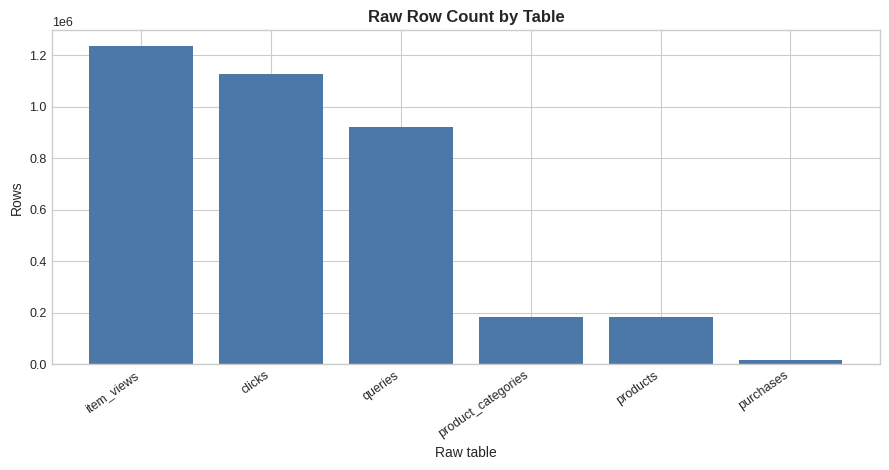

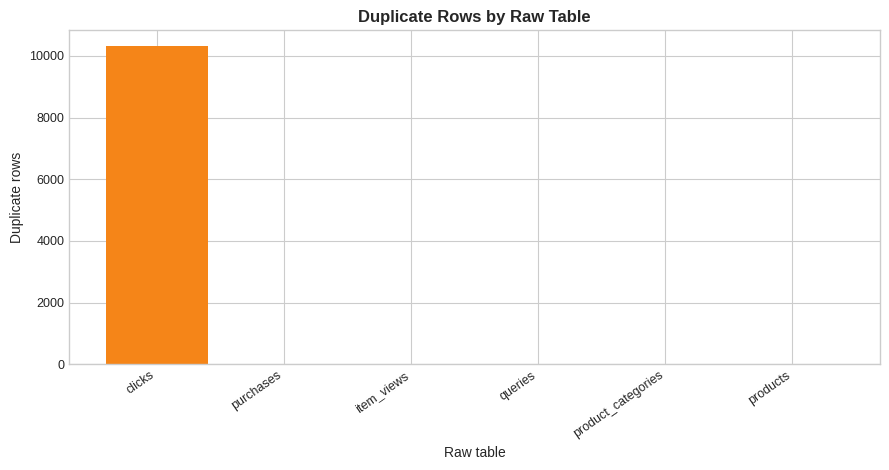

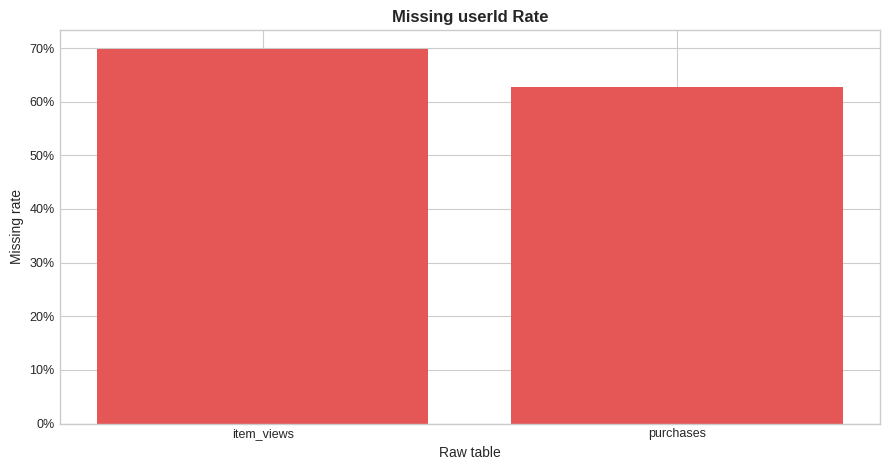

,table,missing_userid_rate,rows
0,item_views,0.698076,1235380
1,purchases,0.628128,18025


In [3]:
bar_chart(
    raw_overview,
    x="table",
    y="rows",
    title="Raw Row Count by Table",
    xlabel="Raw table",
    ylabel="Rows",
    filename="raw_table_rows.png",
    rotation=35,
)

duplicate_overview = raw_overview.sort_values("duplicate_rows", ascending=False)
bar_chart(
    duplicate_overview,
    x="table",
    y="duplicate_rows",
    title="Duplicate Rows by Raw Table",
    xlabel="Raw table",
    ylabel="Duplicate rows",
    filename="raw_table_duplicates.png",
    rotation=35,
    color="#F58518",
)

missing_userid = pd.DataFrame(
    [
        {
            "table": table_name,
            "missing_userid_rate": float(tables[table_name]["userId"].isna().mean()),
            "rows": len(tables[table_name]),
        }
        for table_name in ["item_views", "purchases"]
        if "userId" in tables[table_name].columns
    ]
)
bar_chart(
    missing_userid,
    x="table",
    y="missing_userid_rate",
    title="Missing userId Rate",
    xlabel="Raw table",
    ylabel="Missing rate",
    filename="missing_userid_rate.png",
    color="#E45756",
    percent=True,
)
missing_userid


**Interpretation:** The raw dataset is dominated by interaction rows, especially item views. Because `userId` is heavily missing in the behavior tables, the reliable unit of analysis is the session, not the customer profile. That makes user-level RFM, CLV, or churn unsuitable as the main project framing.


## Column Profile


In [4]:
profile_rows = []
for table_name, df in tables.items():
    missing_rates = df.isna().mean()
    for column in df.columns:
        profile_rows.append(
            {
                "table": table_name,
                "column": column,
                "dtype": str(df[column].dtype),
                "missing_rate": round(float(missing_rates[column]), 6),
                "n_unique": int(df[column].nunique(dropna=True)),
            }
        )

profile_df = pd.DataFrame(profile_rows)
profile_df.sort_values(["table", "missing_rate"], ascending=[True, False])


,table,column,dtype,missing_rate,n_unique
26,clicks,queryId,int64,0.000000,633732
27,clicks,timeframe,int64,0.000000,705543
28,clicks,itemId,int64,0.000000,74637
6,item_views,userId,float64,0.698076,87934
5,item_views,sessionId,int64,0.000000,310324
7,item_views,itemId,int64,0.000000,122993
8,item_views,timeframe,int64,0.000000,644845
9,item_views,eventdate,object,0.000000,152
0,product_categories,itemId,int64,0.000000,184047
1,product_categories,categoryId,int64,0.000000,1217


## Date Parsing


In [5]:
date_rows = []
for table_name, df in tables.items():
    if "eventdate" not in df.columns:
        continue
    parsed = pd.to_datetime(df["eventdate"], errors="coerce")
    raw_missing = df["eventdate"].isna()
    date_rows.append(
        {
            "table": table_name,
            "rows": len(df),
            "raw_missing_dates": int(raw_missing.sum()),
            "parse_failures": int(parsed.isna().sum() - raw_missing.sum()),
            "min_event_date": parsed.min(),
            "max_event_date": parsed.max(),
            "unique_dates": int(parsed.nunique(dropna=True)),
        }
    )

date_profile = pd.DataFrame(date_rows)
date_profile


,table,rows,raw_missing_dates,parse_failures,min_event_date,max_event_date,unique_dates
0,item_views,1235380,0,0,2016-01-01,2016-06-01,152
1,purchases,18025,0,0,2016-01-02,2016-06-17,161
2,queries,923127,0,0,2016-01-01,2016-06-01,152


## Item And Metadata Coverage


In [6]:
def id_set(df: pd.DataFrame, column: str) -> set[int]:
    return set(pd.to_numeric(df[column], errors="coerce").dropna().astype("int64"))

product_items = id_set(tables["products"], "itemId")
coverage_rows = []
for table_name in ["item_views", "purchases", "clicks"]:
    item_ids = id_set(tables[table_name], "itemId")
    covered = item_ids & product_items
    missing = item_ids - product_items
    coverage_rows.append(
        {
            "table": table_name,
            "unique_item_ids": len(item_ids),
            "covered_by_products": len(covered),
            "missing_from_products": len(missing),
            "coverage_rate": round(len(covered) / len(item_ids), 6) if item_ids else None,
        }
    )

category_items = id_set(tables["product_categories"], "itemId")
coverage_rows.extend(
    [
        {
            "table": "products_to_product_categories",
            "unique_item_ids": len(product_items),
            "covered_by_products": len(product_items & category_items),
            "missing_from_products": None,
            "coverage_rate": round(len(product_items & category_items) / len(product_items), 6),
        },
        {
            "table": "product_categories_to_products",
            "unique_item_ids": len(category_items),
            "covered_by_products": len(category_items & product_items),
            "missing_from_products": len(category_items - product_items),
            "coverage_rate": round(len(category_items & product_items) / len(category_items), 6),
        },
    ]
)

item_coverage = pd.DataFrame(coverage_rows)
item_coverage


,table,unique_item_ids,covered_by_products,missing_from_products,coverage_rate
0,item_views,122993,122993,0.0,1.000000
1,purchases,11244,11244,0.0,1.000000
2,clicks,74637,74635,2.0,0.999973
3,products_to_product_categories,184047,184047,NaN,1.000000
4,product_categories_to_products,184047,184047,0.0,1.000000


## Build And Save Cleaned Outputs


In [7]:
clean_item_views = build_clean_item_views(tables["item_views"])
clean_purchases = build_clean_purchases(tables["purchases"])
dim_item = build_dim_item(tables["products"], tables["product_categories"])
dim_item = add_item_popularity_features(dim_item, clean_item_views)
fact_session_summary = build_session_summary(clean_item_views, clean_purchases, dim_item)

processed_root = PROJECT_ROOT / config["outputs"]["processed_root"]
mart_root = PROJECT_ROOT / config["outputs"]["mart_root"]
output_paths = {
    "clean_item_views": processed_root / "clean_item_views.parquet",
    "clean_purchases": processed_root / "clean_purchases.parquet",
    "dim_item": mart_root / "dim_item.parquet",
    "fact_session_summary": mart_root / "fact_session_summary.parquet",
}

save_parquet(clean_item_views, output_paths["clean_item_views"])
save_parquet(clean_purchases, output_paths["clean_purchases"])
save_parquet(dim_item, output_paths["dim_item"])
save_parquet(fact_session_summary, output_paths["fact_session_summary"])

clean_output_summary = pd.DataFrame(
    [
        {
            "name": name,
            "path": str(path.relative_to(PROJECT_ROOT)),
            "rows": len(pd.read_parquet(path)),
            "columns": pd.read_parquet(path).shape[1],
        }
        for name, path in output_paths.items()
    ]
)
clean_output_summary


,name,path,rows,columns
0,clean_item_views,data/processed/clean_item_views.parquet,1235380,5
1,clean_purchases,data/processed/clean_purchases.parquet,17997,6
2,dim_item,data/mart/dim_item.parquet,184047,9
3,fact_session_summary,data/mart/fact_session_summary.parquet,310486,16


## Cleaning Validation


In [8]:
products = tables["products"]
pricelog2_raw = pd.to_numeric(products["pricelog2"], errors="coerce")
raw_price_proxy = (2.0 ** pricelog2_raw) - 1.0

cleaning_validation = pd.DataFrame(
    [
        {
            "products_rows": len(products),
            "missing_pricelog2": int(pricelog2_raw.isna().sum()),
            "raw_non_positive_price_proxy_rows": int(raw_price_proxy.le(0).sum()),
            "valid_price_proxy_rows_after_cleaning": int(dim_item["price_proxy"].notna().sum()),
            "invalid_non_positive_price_proxy_after_cleaning": int(dim_item["price_proxy"].dropna().le(0).sum()),
            "session_length_buckets": sorted(fact_session_summary["session_length_bucket"].dropna().unique().tolist()),
            "item_popularity_buckets": sorted(dim_item["item_popularity_bucket"].dropna().unique().tolist()),
        }
    ]
)
assert cleaning_validation["invalid_non_positive_price_proxy_after_cleaning"].iloc[0] == 0
assert "session_length_bucket" in fact_session_summary.columns
assert "item_popularity_bucket" in dim_item.columns
cleaning_validation


,products_rows,missing_pricelog2,raw_non_positive_price_proxy_rows,valid_price_proxy_rows_after_cleaning,invalid_non_positive_price_proxy_after_cleaning,session_length_buckets,item_popularity_buckets
0,184047,0,58042,126005,0,"[0, 1, 11-20, 2, 21+, 3-5, 6-10]","[1, 101+, 2-5, 21-100, 6-20, unviewed]"


**Interpretation:** The cleaned layer keeps the `pricelog2` formula but treats non-positive `price_proxy` values as missing, so value-oriented KPIs do not treat zero prices as real value. The session summary now has length buckets, and items have simple popularity buckets for recommendation-oriented slicing.


## Session Behavior


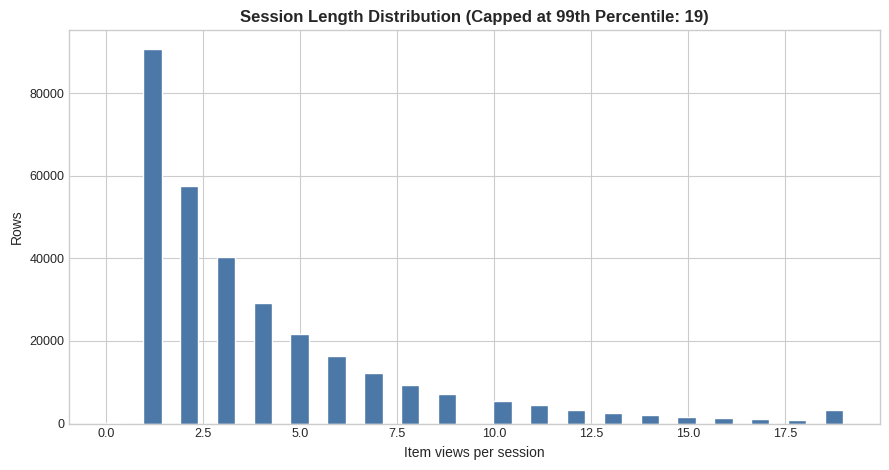

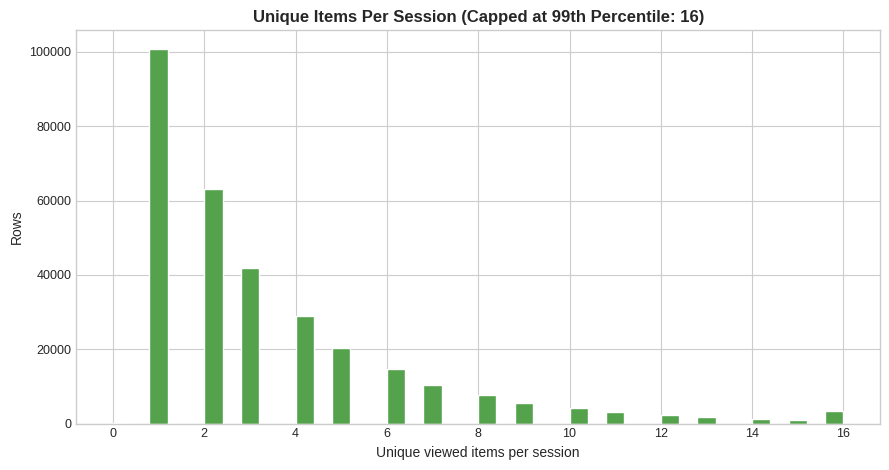

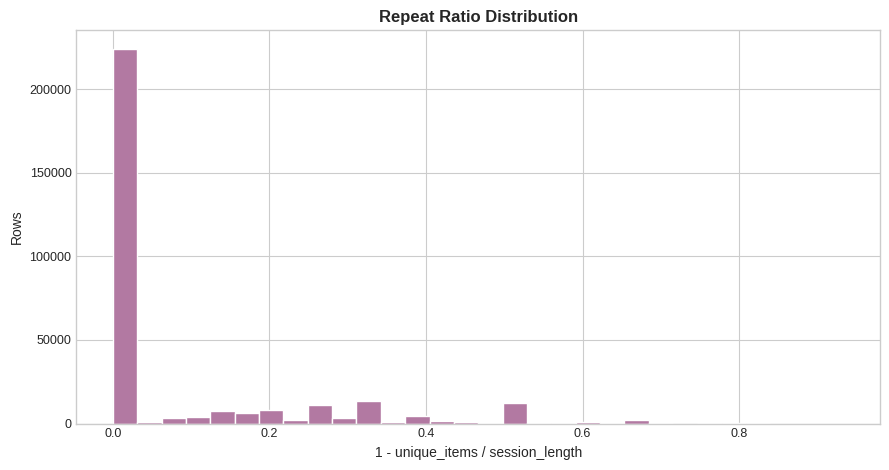

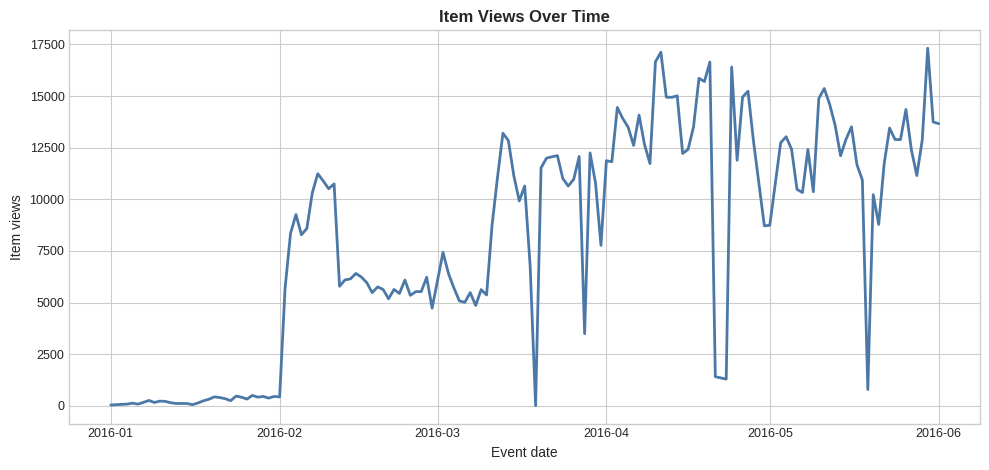

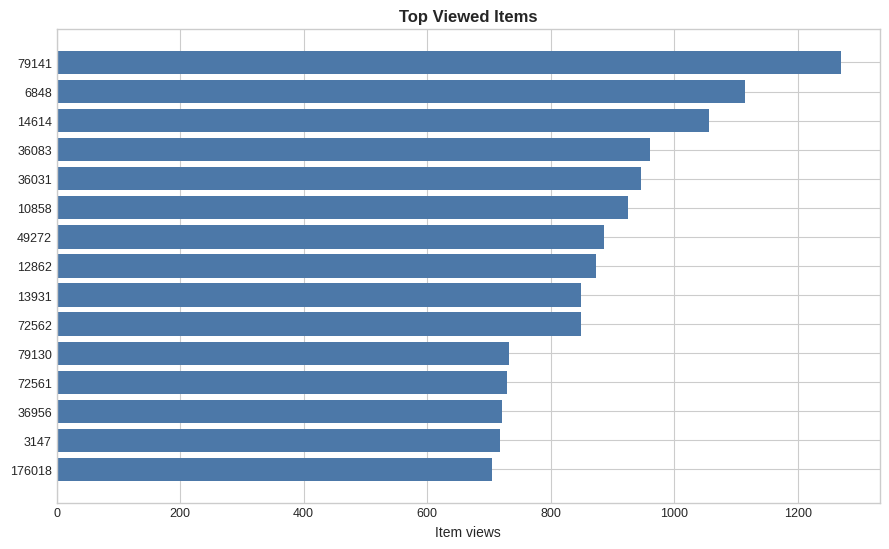

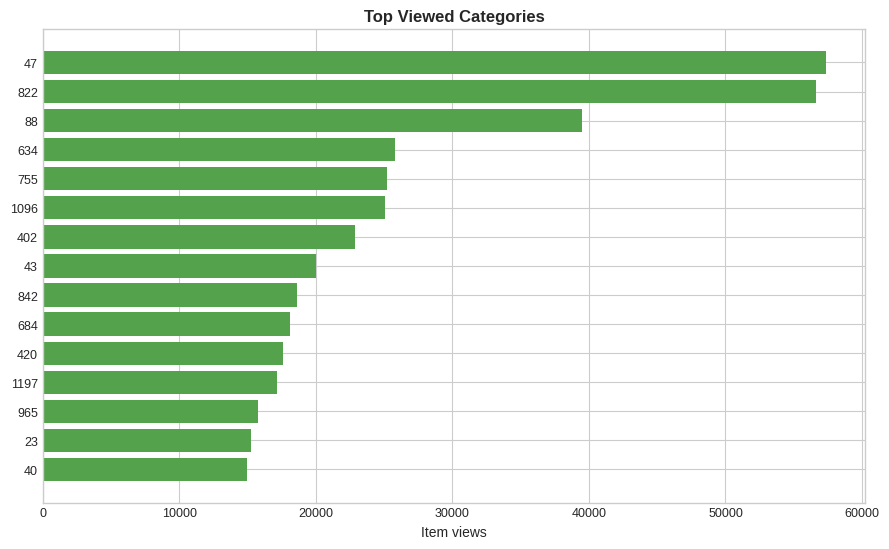

,view_count,unique_viewed_items,repeat_ratio,has_purchase,session_length_bucket
count,310486.0,310486.0,310324.000000,310486,310486
unique,<NA>,<NA>,NaN,2,7
top,<NA>,<NA>,NaN,False,3-5
freq,<NA>,<NA>,NaN,297856,90969
mean,3.978859,3.436764,0.085534,NaN,NaN
std,3.909937,3.267674,0.160626,NaN,NaN
min,0.0,0.0,0.000000,NaN,NaN
25%,1.0,1.0,0.000000,NaN,NaN
50%,3.0,2.0,0.000000,NaN,NaN
75%,5.0,4.0,0.125000,NaN,NaN


In [9]:
session_eda = fact_session_summary.copy()
session_eda["view_count"] = pd.to_numeric(session_eda["view_count"], errors="coerce").fillna(0)
session_eda["unique_viewed_items"] = pd.to_numeric(session_eda["unique_viewed_items"], errors="coerce").fillna(0)
session_eda["repeat_ratio"] = np.where(
    session_eda["view_count"] > 0,
    1.0 - (session_eda["unique_viewed_items"] / session_eda["view_count"]),
    np.nan,
)

length_cap = int(session_eda["view_count"].quantile(0.99))
unique_cap = int(session_eda["unique_viewed_items"].quantile(0.99))

hist_chart(
    session_eda["view_count"].clip(upper=length_cap),
    title=f"Session Length Distribution (Capped at 99th Percentile: {length_cap})",
    xlabel="Item views per session",
    filename="session_length_distribution.png",
    bins=40,
)
hist_chart(
    session_eda["unique_viewed_items"].clip(upper=unique_cap),
    title=f"Unique Items Per Session (Capped at 99th Percentile: {unique_cap})",
    xlabel="Unique viewed items per session",
    filename="unique_items_distribution.png",
    bins=40,
    color="#54A24B",
)
hist_chart(
    session_eda["repeat_ratio"],
    title="Repeat Ratio Distribution",
    xlabel="1 - unique_items / session_length",
    filename="repeat_ratio_distribution.png",
    bins=30,
    color="#B279A2",
)

views_over_time = (
    clean_item_views.assign(event_day=clean_item_views["event_date"].dt.date)
    .groupby("event_day", as_index=False)
    .size()
    .rename(columns={"size": "item_views"})
)
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(pd.to_datetime(views_over_time["event_day"]), views_over_time["item_views"], color="#4C78A8", linewidth=2)
ax.set_title("Item Views Over Time")
ax.set_xlabel("Event date")
ax.set_ylabel("Item views")
save_plot(fig, "views_over_time.png")

top_viewed_items = (
    clean_item_views["item_id"]
    .value_counts()
    .head(15)
    .rename_axis("item_id")
    .reset_index(name="view_count")
)
barh_chart(
    top_viewed_items,
    label_col="item_id",
    value_col="view_count",
    title="Top Viewed Items",
    xlabel="Item views",
    filename="top_viewed_items.png",
    color="#4C78A8",
)

view_categories = clean_item_views.merge(
    dim_item[["item_id", "primary_category_id"]], on="item_id", how="left"
)
top_viewed_categories = (
    view_categories.dropna(subset=["primary_category_id"])
    .groupby("primary_category_id", as_index=False)
    .size()
    .rename(columns={"size": "view_count"})
    .sort_values("view_count", ascending=False)
    .head(15)
)
barh_chart(
    top_viewed_categories,
    label_col="primary_category_id",
    value_col="view_count",
    title="Top Viewed Categories",
    xlabel="Item views",
    filename="top_viewed_categories.png",
    color="#54A24B",
)

session_eda[["view_count", "unique_viewed_items", "repeat_ratio", "has_purchase", "session_length_bucket"]].describe(include="all")


**Interpretation:** Sessions are short sequential journeys with a long tail. The histograms show why next-item recommendation is a natural problem: each row sequence contains enough local context to predict the next click, while repeat behavior and category concentration show session intent that does not require a stable user profile. This supports an SR-GNN framing because SR-GNN models item transitions inside each session graph.


## Purchase And Value Proxy


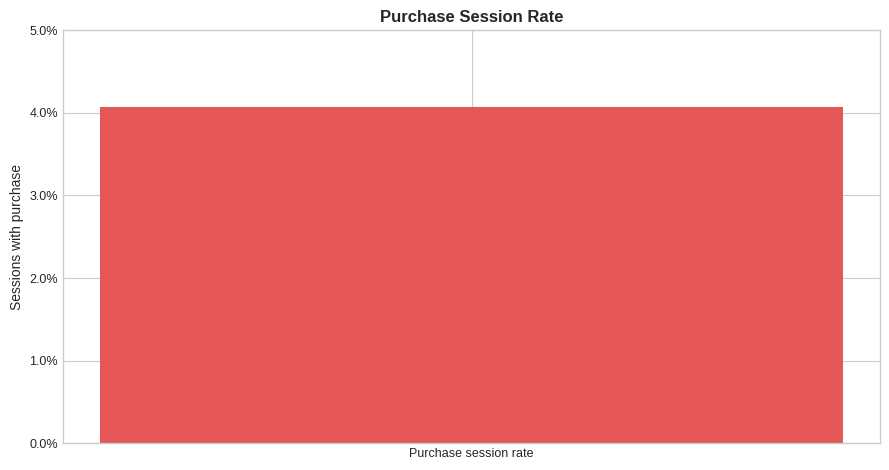

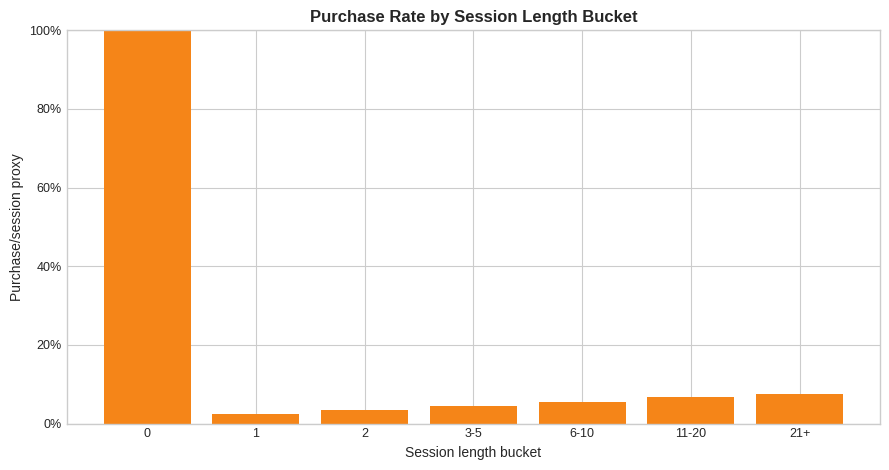

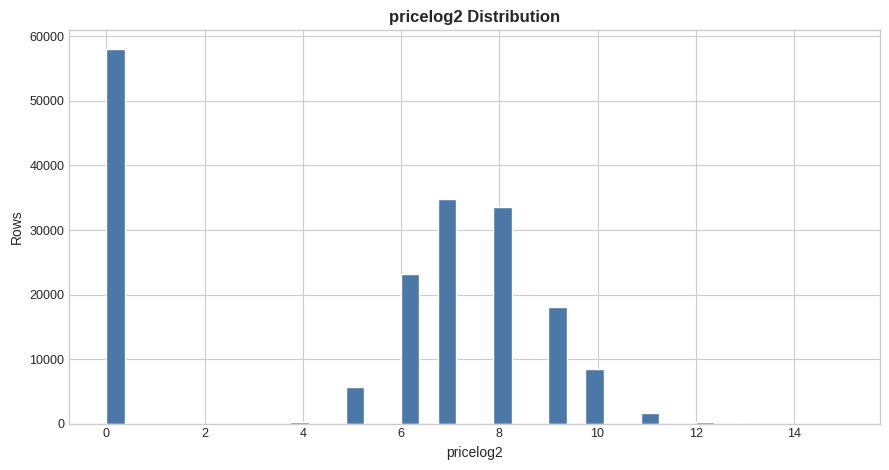

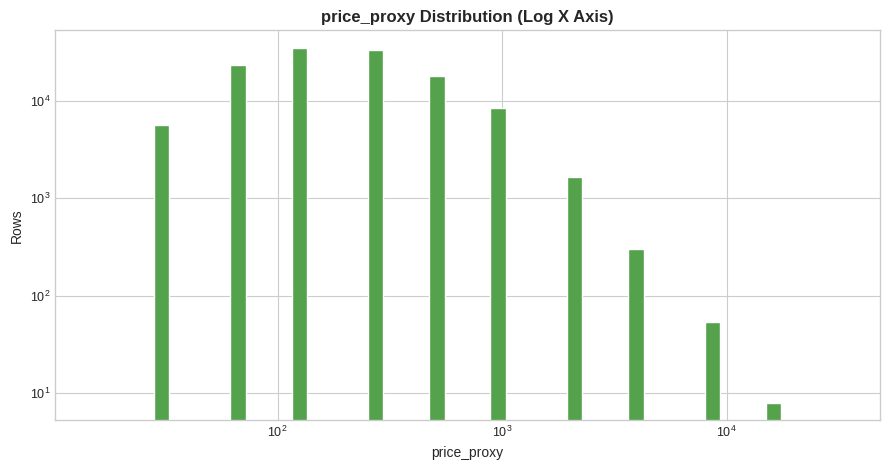

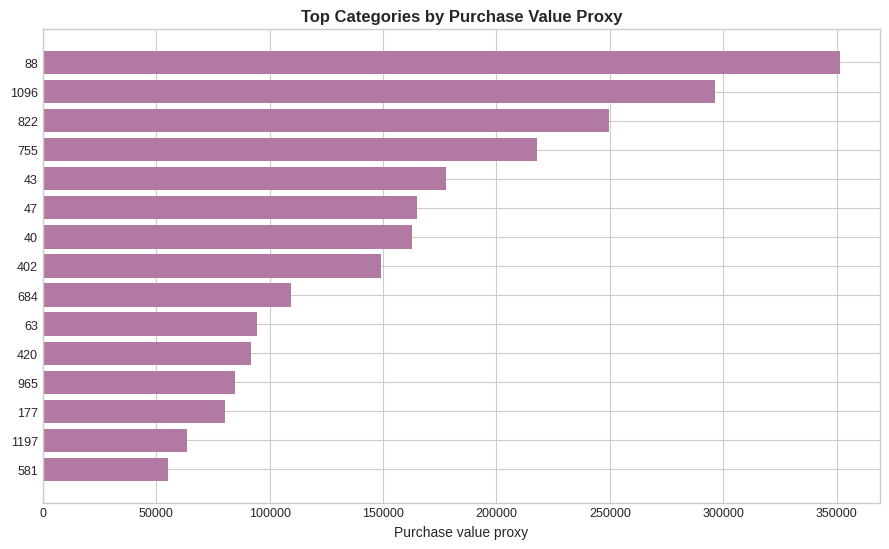

,sessions,purchase_sessions,purchase_session_rate,valid_price_proxy_items,missing_price_proxy_items
0,310486,12630,0.040678,126005,58042


In [10]:
purchase_session_rate = float(fact_session_summary["has_purchase"].fillna(False).mean())
purchase_session_rate_df = pd.DataFrame(
    [{"metric": "Purchase session rate", "rate": purchase_session_rate}]
)
bar_chart(
    purchase_session_rate_df,
    x="metric",
    y="rate",
    title="Purchase Session Rate",
    xlabel="",
    ylabel="Sessions with purchase",
    filename="purchase_session_rate.png",
    color="#E45756",
    percent=True,
)

purchase_rate_by_bucket = (
    fact_session_summary.assign(
        session_length_bucket=pd.Categorical(
            fact_session_summary["session_length_bucket"], categories=SESSION_BUCKET_ORDER, ordered=True
        )
    )
    .groupby("session_length_bucket", observed=False)["has_purchase"]
    .mean()
    .reset_index(name="purchase_session_rate")
    .dropna(subset=["session_length_bucket"])
)
bar_chart(
    purchase_rate_by_bucket,
    x="session_length_bucket",
    y="purchase_session_rate",
    title="Purchase Rate by Session Length Bucket",
    xlabel="Session length bucket",
    ylabel="Purchase/session proxy",
    filename="purchase_rate_by_session_length.png",
    color="#F58518",
    percent=True,
)

hist_chart(
    pricelog2_raw,
    title="pricelog2 Distribution",
    xlabel="pricelog2",
    filename="pricelog2_distribution.png",
    bins=40,
    color="#4C78A8",
)
hist_chart(
    dim_item["price_proxy"],
    title="price_proxy Distribution (Log X Axis)",
    xlabel="price_proxy",
    filename="price_proxy_distribution.png",
    bins=50,
    color="#54A24B",
    log_x=True,
    log_y=True,
)

purchase_items = clean_purchases.merge(
    dim_item[["item_id", "primary_category_id", "price_proxy"]], on="item_id", how="left"
)
purchase_value_by_category = (
    purchase_items.dropna(subset=["primary_category_id"])
    .groupby("primary_category_id", as_index=False)
    .agg(
        purchase_count=("item_id", "size"),
        purchase_value_proxy=("price_proxy", "sum"),
    )
    .sort_values("purchase_value_proxy", ascending=False)
    .head(15)
)
barh_chart(
    purchase_value_by_category,
    label_col="primary_category_id",
    value_col="purchase_value_proxy",
    title="Top Categories by Purchase Value Proxy",
    xlabel="Purchase value proxy",
    filename="purchase_value_proxy_by_category.png",
    color="#B279A2",
)

pd.DataFrame(
    [
        {
            "sessions": len(fact_session_summary),
            "purchase_sessions": int(fact_session_summary["has_purchase"].sum()),
            "purchase_session_rate": purchase_session_rate,
            "valid_price_proxy_items": int(dim_item["price_proxy"].notna().sum()),
            "missing_price_proxy_items": int(dim_item["price_proxy"].isna().sum()),
        }
    ]
)


**Interpretation:** Purchases are sparse, so purchase/session is a proxy signal rather than the main target. The price field supports value-oriented offline KPIs, but it is still a `price_proxy`, not audited revenue. This keeps the business story focused on offline next-click capture and value-proxy weighting.


## Recommendation-Oriented EDA


In [11]:
mart_root = PROJECT_ROOT / config["outputs"]["mart_root"]
fact_metrics_path = mart_root / "fact_metrics.parquet"
fact_eval_path = mart_root / "fact_recommendation_eval.parquet"
fact_kpis_path = mart_root / "fact_marketing_kpis.parquet"

recommendation_artifacts_available = fact_metrics_path.exists() and fact_eval_path.exists()
recommendation_artifacts_available


True

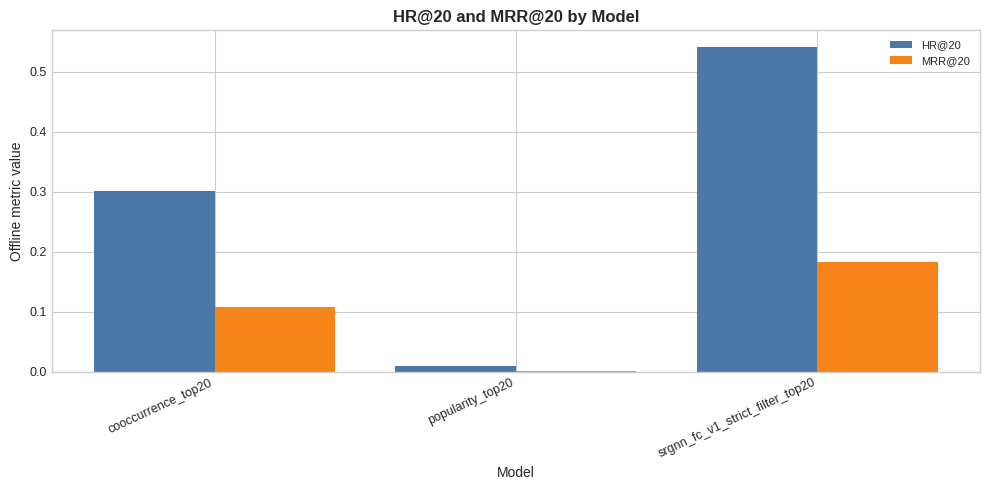

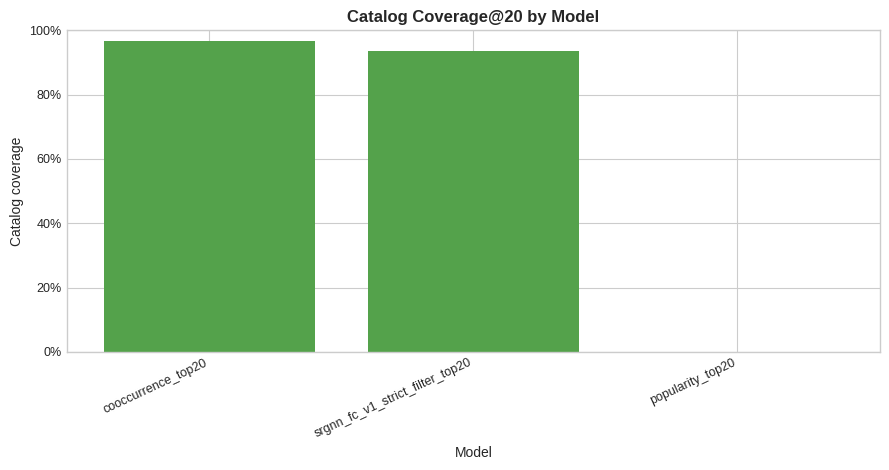

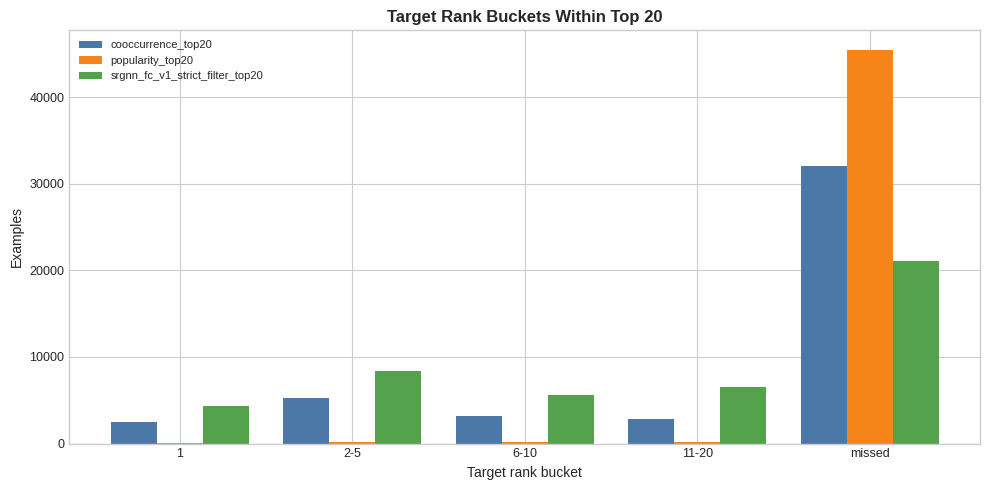

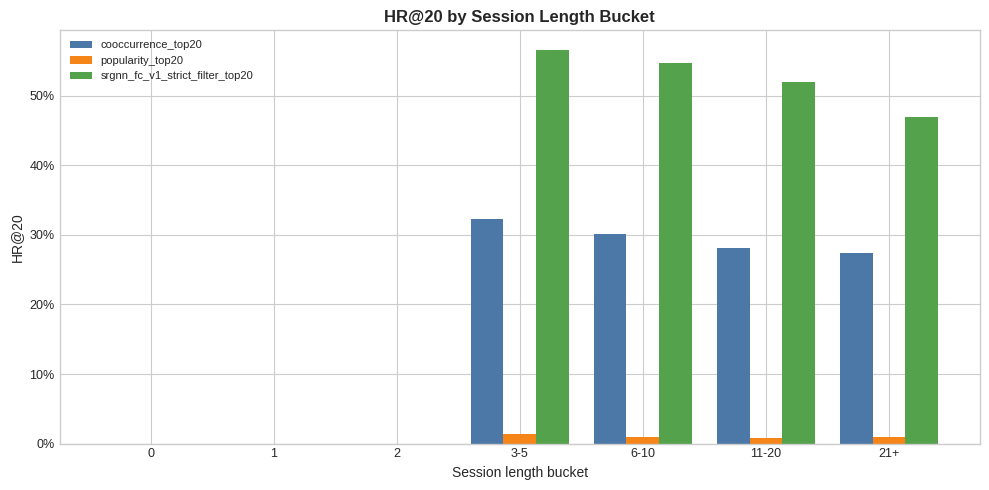

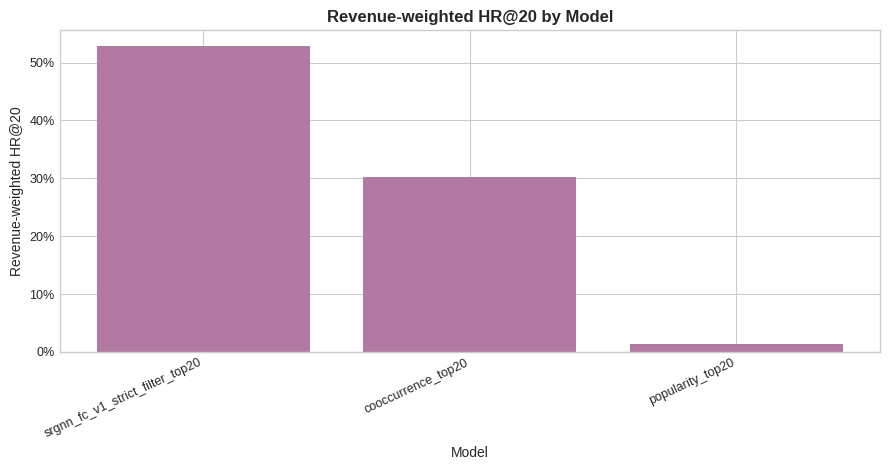

,model_key,metric_name,metric_value,k,metric_scope,source,warning_text
8,cooccurrence_top20,Catalog Coverage@20,0.966713,20,offline_test,computed_train_only_baseline,Offline next-click metric; not real CTR or causal business impact.
2,srgnn_fc_v1_strict_filter_top20,Catalog Coverage@20,0.935506,20,offline_test,inherited_prediction_rows,Offline next-click metric; not real CTR or causal business impact.
5,popularity_top20,Catalog Coverage@20,0.000867,20,offline_test,computed_train_only_baseline,Offline next-click metric; not real CTR or causal business impact.
0,srgnn_fc_v1_strict_filter_top20,HR@20,0.541625,20,offline_test,inherited_prediction_rows,Offline next-click metric; not real CTR or causal business impact.
6,cooccurrence_top20,HR@20,0.300849,20,offline_test,computed_train_only_baseline,Offline next-click metric; not real CTR or causal business impact.
3,popularity_top20,HR@20,0.010216,20,offline_test,computed_train_only_baseline,Offline next-click metric; not real CTR or causal business impact.
1,srgnn_fc_v1_strict_filter_top20,MRR@20,0.183158,20,offline_test,inherited_prediction_rows,Offline next-click metric; not real CTR or causal business impact.
7,cooccurrence_top20,MRR@20,0.108070,20,offline_test,computed_train_only_baseline,Offline next-click metric; not real CTR or causal business impact.
4,popularity_top20,MRR@20,0.002296,20,offline_test,computed_train_only_baseline,Offline next-click metric; not real CTR or causal business impact.


In [12]:
if recommendation_artifacts_available:
    fact_metrics = pd.read_parquet(fact_metrics_path)
    fact_eval = pd.read_parquet(fact_eval_path)
    fact_kpis = pd.read_parquet(fact_kpis_path) if fact_kpis_path.exists() else pd.DataFrame()

    if "session_length_bucket" not in fact_eval.columns and "session_length_bucket" in fact_session_summary.columns:
        fact_eval = fact_eval.merge(
            fact_session_summary[["session_id", "session_length_bucket"]], on="session_id", how="left"
        )

    hr_mrr = fact_metrics[fact_metrics["metric_name"].isin([f"HR@{top_k}", f"MRR@{top_k}"])].copy()
    grouped_bar_chart(
        hr_mrr,
        x="model_key",
        group="metric_name",
        y="metric_value",
        title=f"HR@{top_k} and MRR@{top_k} by Model",
        xlabel="Model",
        ylabel="Offline metric value",
        filename="model_hr_mrr_comparison.png",
        percent=False,
        rotation=25,
    )

    coverage = fact_metrics[fact_metrics["metric_name"].eq(f"Catalog Coverage@{top_k}")].copy()
    if not coverage.empty:
        bar_chart(
            coverage.sort_values("metric_value", ascending=False),
            x="model_key",
            y="metric_value",
            title=f"Catalog Coverage@{top_k} by Model",
            xlabel="Model",
            ylabel="Catalog coverage",
            filename="model_catalog_coverage.png",
            rotation=25,
            color="#54A24B",
            percent=True,
        )

    rank_bucket = fact_eval.copy()
    rank_bucket["rank_bucket"] = pd.cut(
        pd.to_numeric(rank_bucket["target_rank"], errors="coerce"),
        bins=[0, 1, 5, 10, top_k],
        labels=["1", "2-5", "6-10", "11-20"],
        include_lowest=True,
    ).astype("string")
    rank_bucket["rank_bucket"] = rank_bucket["rank_bucket"].fillna("missed")
    rank_bucket["rank_bucket"] = pd.Categorical(
        rank_bucket["rank_bucket"], categories=RANK_BUCKET_ORDER, ordered=True
    )
    rank_bucket_summary = (
        rank_bucket.groupby(["rank_bucket", "model_key"], observed=False)
        .size()
        .reset_index(name="examples")
    )
    grouped_bar_chart(
        rank_bucket_summary,
        x="rank_bucket",
        group="model_key",
        y="examples",
        title=f"Target Rank Buckets Within Top {top_k}",
        xlabel="Target rank bucket",
        ylabel="Examples",
        filename="target_rank_distribution.png",
    )

    if "session_length_bucket" in fact_eval.columns:
        hr_by_session_length = (
            fact_eval.assign(
                session_length_bucket=pd.Categorical(
                    fact_eval["session_length_bucket"], categories=SESSION_BUCKET_ORDER, ordered=True
                )
            )
            .dropna(subset=["session_length_bucket"])
            .groupby(["session_length_bucket", "model_key"], observed=False)["hit_at_k"]
            .mean()
            .reset_index(name="hr_at_k")
        )
        grouped_bar_chart(
            hr_by_session_length,
            x="session_length_bucket",
            group="model_key",
            y="hr_at_k",
            title=f"HR@{top_k} by Session Length Bucket",
            xlabel="Session length bucket",
            ylabel=f"HR@{top_k}",
            filename="hr_by_session_length_bucket.png",
            percent=True,
        )

    value_metric_name = f"Revenue-weighted HR@{top_k}"
    if not fact_kpis.empty and value_metric_name in set(fact_kpis["kpi_name"]):
        value_proxy = fact_kpis[fact_kpis["kpi_name"].eq(value_metric_name)].copy()
        bar_chart(
            value_proxy.sort_values("kpi_value", ascending=False),
            x="model_key",
            y="kpi_value",
            title=value_metric_name + " by Model",
            xlabel="Model",
            ylabel=value_metric_name,
            filename="value_proxy_by_model.png",
            rotation=25,
            color="#B279A2",
            percent=True,
        )

    recommendation_summary = fact_metrics.sort_values(["metric_name", "metric_value"], ascending=[True, False])
else:
    recommendation_summary = pd.DataFrame(
        [{"message": "Recommendation mart files are not available yet. Run `make metrics` or `make marts`."}]
    )

recommendation_summary


**Interpretation:** Recommendation metrics remain offline proxies. HR@20 shows next-click capture, MRR@20 shows how early the target appears, coverage shows catalog breadth, and rank buckets show where successful captures land. These charts support SR-GNN as a reasonable solution when session transition structure matters, without claiming real CTR, causal uplift, ROAS, or real revenue.


## Figure Inventory


In [13]:
figure_inventory = pd.DataFrame(
    [{"figure": path.name, "path": str(path.relative_to(PROJECT_ROOT)), "exists": path.exists()} for path in figures_generated]
).drop_duplicates()
assert figure_inventory["exists"].all()
figure_inventory


,figure,path,exists
0,raw_table_rows.png,reports/figures/raw_table_rows.png,True
1,raw_table_duplicates.png,reports/figures/raw_table_duplicates.png,True
2,missing_userid_rate.png,reports/figures/missing_userid_rate.png,True
3,session_length_distribution.png,reports/figures/session_length_distribution.png,True
4,unique_items_distribution.png,reports/figures/unique_items_distribution.png,True
5,repeat_ratio_distribution.png,reports/figures/repeat_ratio_distribution.png,True
6,views_over_time.png,reports/figures/views_over_time.png,True
7,top_viewed_items.png,reports/figures/top_viewed_items.png,True
8,top_viewed_categories.png,reports/figures/top_viewed_categories.png,True
9,purchase_session_rate.png,reports/figures/purchase_session_rate.png,True


## Known Limitations

- The raw Diginetica tables do not include recommendation impression logs, so this project cannot compute real CTR.
- `CTR Proxy@20` means offline `Hit Rate@20` in business language.
- `products.pricelog2` is converted with `price_proxy = 2^pricelog2 - 1`; non-positive proxies are treated as missing.
- Purchase/session and value-proxy fields are offline proxy evidence only.
- Do not claim real revenue, causal conversion uplift, ROAS, or recommendation-caused purchases from this layer.
